# ERPy quick start: a deidentified cohort recording

Inspect an actual recording from the CNS/ACC–PAG analysis cohort, preserve its source trial QC, and recompute fixed-window reproducibility and matched excess energy.

The stored figures are derived from an actual deidentified CNS/ACC–PAG cohort recording. Restricted trial data are not distributed. Reexecution requires the authorized local source export via ERPY_COHORT_EXAMPLE_DIR; there is no synthetic or public-dataset substitution. Display labels are anatomical.

In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Allow this notebook to run from JupyterLab or from the repository root.
HERE = Path.cwd()
EXAMPLES = HERE if (HERE / "_synthetic.py").exists() else HERE / "notebooks" / "examples"
sys.path.insert(0, str(EXAMPLES.resolve()))
REPOSITORY = EXAMPLES.parents[1]
if (REPOSITORY / "ERPy").exists():
    sys.path.insert(0, str(REPOSITORY.resolve()))

import ERPy as ep
import ERPy.viz as viz
from IPython.display import Image, display as show_output
from _synthetic import (
    make_detection_table,
    make_edges,
    make_electrode_metadata,
    make_epochs,
    make_metric_table,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

# The publication workflow stores PNGs so the figures render directly on GitHub.
get_ipython().run_line_magic("matplotlib", "inline")

def show_plotly_snapshot(figure):
    # Use figure.show() to interact locally; these PNGs also render on GitHub.
    import plotly.graph_objects as go
    preview = go.Figure(figure)
    preview.layout.sliders = ()
    preview.layout.updatemenus = ()
    preview.update_layout(
        legend={"orientation": "h", "y": -0.08, "x": 0.05},
        margin={"l": 30, "r": 100, "t": 65, "b": 70},
    )
    show_output(Image(preview.to_image(format="png", width=1000, height=650, scale=1)))

In [2]:
import json
from _cohort import load_cohort_example, DISPLAY_CHANNEL

# Set ERPY_COHORT_EXAMPLE_DIR in the kernel environment to the authorized
# method-example directory. The loader verifies the exact input checksum.
epochs, trial_qc, provenance = load_cohort_example()
print(f"Python {platform.python_version()}")
print(f"ERPy {ep.__version__}: {epochs.n_trials()} trials, {len(epochs.channels)} channels")
print(json.dumps(provenance, indent=2))
trial_qc.groupby("source_status").size().rename("Trials").to_frame()

Python 3.12.14
ERPy 1.0.0: 25 trials, 1 channels
{
  "data_source": "deidentified CNS/ACC\u2013PAG cohort recording",
  "stimulation": "ACC stimulation",
  "recording": "Subgenual cingulate recording",
  "input_sha256": "918a15e56a857f173d41d7b29dbe6e92bd06c20915e5ae56805d64b3a35b55ad",
  "n_trials": 25,
  "n_source_retained": 25,
  "sampling_hz": 2000.0,
  "exported_window_ms": [
    -400.0,
    600.0
  ],
  "selection": "previously selected method illustration; outcome-enriched",
  "analysis_scope": "one exported recording contact; acquisition family unavailable in this export"
}


,Trials
source_status,
retained,25


In [3]:
values = epochs.epochs_df[DISPLAY_CHANNEL].unstack("time").to_numpy()
times = epochs.times
source_retained = trial_qc.source_status.eq("retained").to_numpy()
retained_values = values[source_retained]
config = ep.CRPEnergyConfig(
    response_window=(0.015, 0.300), baseline_window=(-0.400, -0.030),
    artifact_interval=(0.0, 0.015), min_clean_trials=8,
    alpha=0.05, correction="none", n_permutations=5_000, random_state=42,
)
result = ep.run_crp_energy_array(
    retained_values, times, channel=DISPLAY_CHANNEL, config=config,
)
pd.Series({
    "Source-retained trials": int(source_retained.sum()),
    "Finite trials used by both components": result.n_trials_clean,
    "Fixed-window p_R": result.p_crp,
    "Matched-energy p_E": result.p_energy,
    "Unadjusted p_joint = max(p_R, p_E)": result.p_joint,
    "Unadjusted component class": result.classification,
    "Matched response/baseline RMS ratio (dB)": result.rms_ratio_db,
    "Response window (s)": result.response_window,
    "Matched baseline window (s)": result.baseline_window,
}, name="Selected recording results").to_frame()

,Selected recording results
Source-retained trials,25
Finite trials used by both components,25
Fixed-window p_R,0.0002
Matched-energy p_E,0.0002
"Unadjusted p_joint = max(p_R, p_E)",0.0002
Unadjusted component class,reproducible_energetic
Matched response/baseline RMS ratio (dB),10.195104
Response window (s),"(0.015, 0.3)"
Matched baseline window (s),"(-0.315, -0.03)"


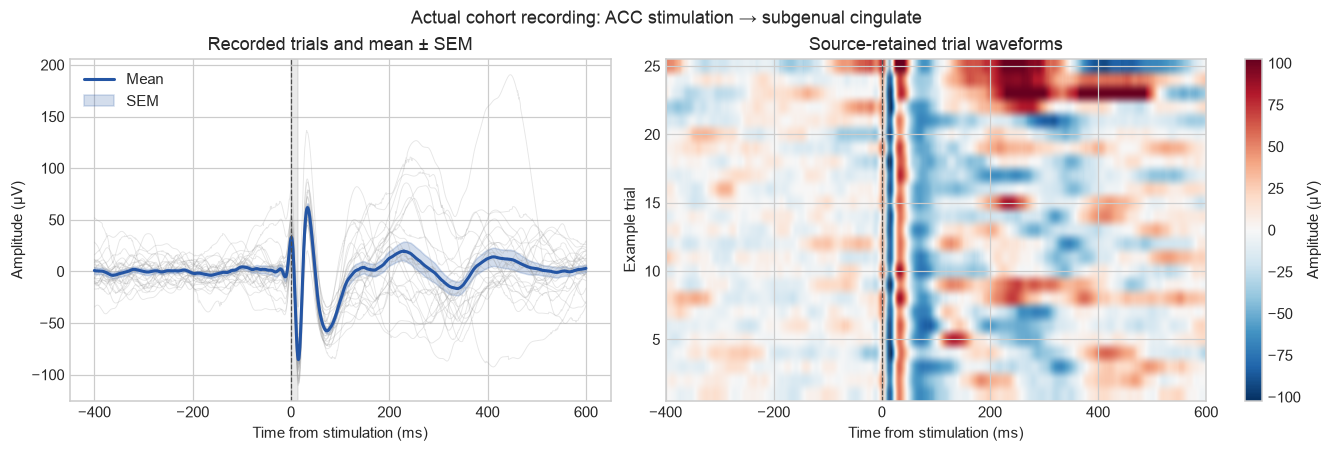

In [4]:
# The source export retains the original processed amplitudes. Center each
# trial over the declared prestimulus interval for the waveform display only.
baseline = (times >= config.baseline_window[0]) & (times <= config.baseline_window[1])
display_values = retained_values - retained_values[:, baseline].mean(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes[0].plot(times * 1000, display_values.T, color="0.6", alpha=0.24, linewidth=0.6)
mean = display_values.mean(axis=0)
sem = display_values.std(axis=0, ddof=1) / np.sqrt(len(display_values))
axes[0].plot(times * 1000, mean, color="#2455A4", linewidth=2, label="Mean")
axes[0].fill_between(times * 1000, mean-sem, mean+sem, color="#2455A4", alpha=0.2, label="SEM")
axes[0].legend()
axes[0].set(xlabel="Time from stimulation (ms)", ylabel="Amplitude (µV)", title="Recorded trials and mean ± SEM")
limit = np.quantile(np.abs(display_values), 0.99)
heat = axes[1].imshow(display_values, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-limit, vmax=limit,
                      extent=[times[0]*1000, times[-1]*1000, 0.5, len(display_values)+0.5])
axes[1].set(xlabel="Time from stimulation (ms)", ylabel="Example trial", title="Source-retained trial waveforms")
fig.colorbar(heat, ax=axes[1], label="Amplitude (µV)")
for ax in axes:
    ax.axvspan(0, 15, color="0.5", alpha=0.16)
    ax.axvline(0, color="0.3", linewidth=0.8, linestyle="--")
fig.suptitle("Actual cohort recording: ACC stimulation → subgenual cingulate")
plt.show()

Both components use the same finite source-retained trials. The `p_crp` field
in this result stores the fixed-window whole-trial reproducibility value
$p_R$; matched excess energy is assessed after separately demeaning response
and baseline. Their maximum is the unadjusted conjunction value.

This export contains one previously selected recording contact. Its original
selection favored clear method examples, so it cannot estimate detection
accuracy or response prevalence. We do not reconstruct the original
acquisition-wide testing family, report a family-adjusted response call, or
claim a new cohort analysis here. The 15–300 ms computation above is a fresh
ERPy analysis of the exported trials; it is distinct from the generating
analysis's selected-duration CRP comparator and 15–350 ms energy example.

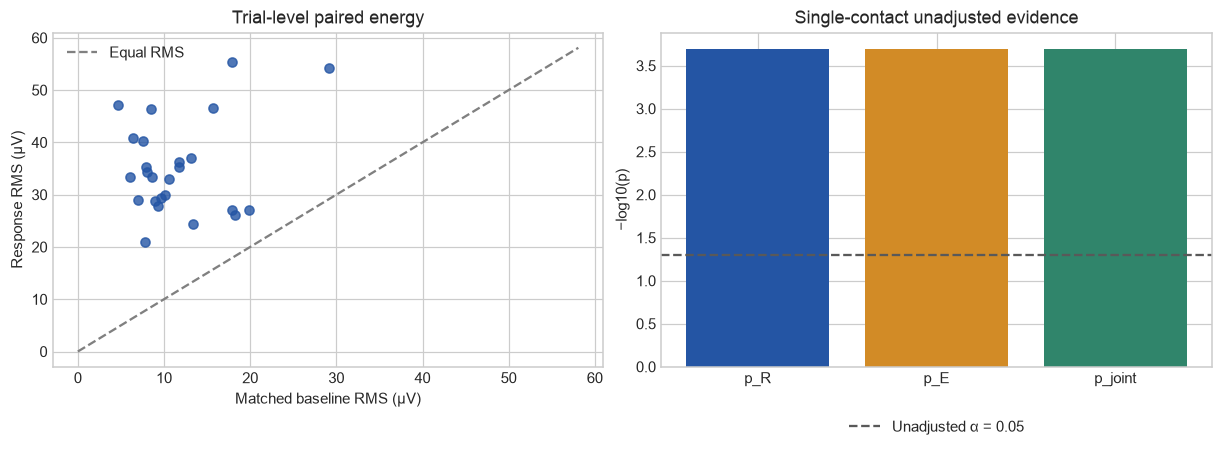

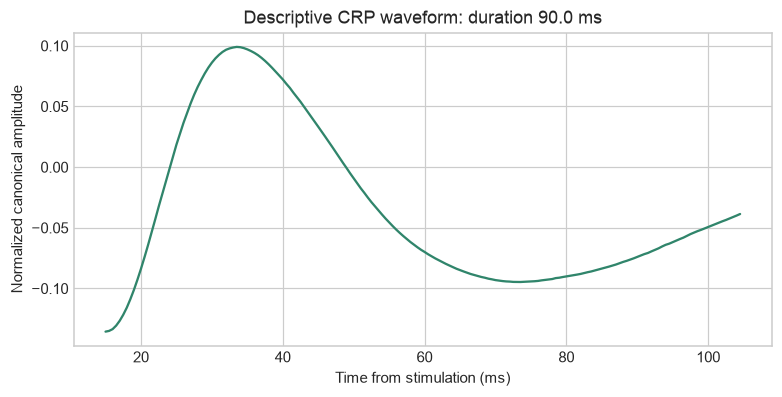

In [5]:
# Inspect matched, separately demeaned trial energies used by the component.
response = (times >= result.response_window[0]) & (times <= result.response_window[1])
matched_baseline = (times >= result.baseline_window[0]) & (times <= result.baseline_window[1])
used = retained_values[result.clean_trial_indices]
def demeaned_rms(segment):
    return np.sqrt(np.mean((segment - segment.mean(axis=1, keepdims=True)) ** 2, axis=1))
baseline_rms = demeaned_rms(used[:, matched_baseline])
response_rms = demeaned_rms(used[:, response])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].scatter(baseline_rms, response_rms, color="#2455A4", alpha=0.8)
maximum = max(baseline_rms.max(), response_rms.max()) * 1.05
axes[0].plot([0, maximum], [0, maximum], "--", color="0.5", label="Equal RMS")
axes[0].set(xlabel="Matched baseline RMS (µV)", ylabel="Response RMS (µV)", title="Trial-level paired energy")
axes[0].legend()
p_values = [result.p_crp, result.p_energy, result.p_joint]
axes[1].bar(["p_R", "p_E", "p_joint"], -np.log10(p_values), color=["#2455A4", "#D28B26", "#30856B"])
axes[1].axhline(-np.log10(config.alpha), linestyle="--", color="0.35", label="Unadjusted α = 0.05")
axes[1].set(ylabel="−log10(p)", title="Single-contact unadjusted evidence")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5), layout="constrained")
ax.plot(result.canonical_waveform_times*1000, result.canonical_waveform, color="#30856B")
ax.set(xlabel="Time from stimulation (ms)", ylabel="Normalized canonical amplitude",
       title=f"Descriptive CRP waveform: duration {result.response_duration*1000:.1f} ms")
plt.show()

The gray interval marks the declared 0–15 ms exclusion. The source trial QC
and processed signal are reused from the generating cohort analysis; this
notebook does not repeat continuous-data filtering, event extraction, or
artifact detection. The canonical waveform is a descriptive view and does
not select the primary fixed inference window. Synthetic visualization
fixtures follow in notebooks 01–06, and the independent public OpenNeuro
portability example remains in notebook 07.